## Which of ABL Bio's 37 families cover NEOK001 specifically

Examining the list of patents ABL Bio has, and specifically focusing on those related to NEOK-001:

**Patent Family 8 - ACTIVE** 
Title: Anti-B7-H3 antibody and use thereof
Lens ID: 040-924-461-597-34X
- Anti-B7-H3 monoantibody -> Protection of the B7-H3 arm

**Patent Family 10 - ACTIVE** 
Title: Anti-ROR1 antibody and use thereof
Lens ID: 132-024-389-417-675
- Anti-ROR1 monoantibody -> Protection of the ROR1 arm

**Patent Family 24 - PENDING**  
Title: ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY COMPRISING SAME, AND USES THEREOF  
Lens ID: 085-693-226-467-972  
- Anti-ROR1 bispecific -> Protection of bispecific ROR1 format

**Patent Family 16 - PENDING**  
Title: Conjugado de anticorpo-fármaco compreendendo anticorpo contra ror1 humano e uso para o mesmo  
Lens ID: 130-301-980-653-720  
- Anti-ROR1 ADC -> Protection of the ROR1 ADC format

**Patent Family 34 - PENDING**  
Title: -B7-H3 - Antibody-drug conjugate comprising anti-B7-H3 antibody and its use
Lens ID: 051-245-872-017-682
- anti-B7-H3 ADC -> Protection of the B7-H3 ADC format

**Patent Family 29 - PENDING**  
Title: ANTIBODY THAT BINDS TO ROR1 AND B7-H3, ANTIBODY-DRUG CONJUGATE CONTAINING SAME, AND USE THEREOF  
Lens ID: 063-625-262-975-971  
- Bispecific ROR1+B7-H3 ADC -> Core NEOK-001 asset patent

**Patent Family 33 - PENDING**  
Title: ROR1 and B7-H3 binding antibody-drug conjugate and use thereof
Lens ID: 141-269-859-464-516
- ROR1+B7-H3 ADC with linker chemistry -> Core NEOK-001 asset patent

_Note family number is based on location in csv file, not related to actual order of patents_

In [3]:
import pandas as pd

own_abl = pd.read_csv("../data/raw/abl-37.csv")
own_abl['Owners'] = own_abl['Owners'].fillna(own_abl['Applicants'])

print(own_abl.shape)

# check all NEOK001 matches
for lid in ['132-024-389-417-675', '040-924-461-597-34X',
            '141-269-859-464-516', '130-301-980-653-720',
            '063-625-262-975-971', '085-693-226-467-972',
            '051-245-872-017-682']:
    match = own_abl[own_abl['Lens ID'] == lid]
    print(f"{lid}: {len(match)} matches")

(37, 37)
132-024-389-417-675: 1 matches
040-924-461-597-34X: 1 matches
141-269-859-464-516: 1 matches
130-301-980-653-720: 1 matches
063-625-262-975-971: 1 matches
085-693-226-467-972: 1 matches
051-245-872-017-682: 1 matches


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

neok001_families = {
    'Core Bispecific ADC': [
        '063-625-262-975-971',  # Family 29 - ROR1+B7H3 ADC
        '141-269-859-464-516',  # Family 33 - ROR1+B7H3 ADC linker
    ],
    'ADC Format': [
        '130-301-980-653-720',  # Family 16 - ROR1 ADC
        '051-245-872-017-682',  # Family 34 - B7H3 ADC
    ],
    'Bispecific Format': [
        '085-693-226-467-972',  # Family 24 - ROR1 bispecific
    ],
    'Antibody Arms': [
        '132-024-389-417-675',  # Family 10 - anti-ROR1
        '040-924-461-597-34X',  # Family 8  - anti-B7H3
    ]
}

rows = []
for layer, ids in neok001_families.items():
    for lid in ids:
        rows.append({'lens_id': lid, 'layer': layer})

neok001_df = pd.DataFrame(rows)

abl_cols = own_abl[['Lens ID', 'Title', 'Legal Status', 'Earliest Priority Date']].copy()
abl_cols.columns = ['lens_id', 'title', 'status', 'priority_date']
abl_cols['priority_date'] = pd.to_datetime(abl_cols['priority_date'])
abl_cols['expiry_date'] = abl_cols['priority_date'] + pd.DateOffset(years=20)
abl_cols['years_to_expiry'] = (abl_cols['expiry_date'] - pd.Timestamp.now()).dt.days / 365

neok001_df = neok001_df.merge(abl_cols, on='lens_id', how='left')
neok001_df['short_title'] = neok001_df['title'].str[:45]

print(neok001_df[['layer', 'short_title', 'status', 'priority_date', 'expiry_date', 'years_to_expiry']])

                 layer                                    short_title  \
0  Core Bispecific ADC  ANTIBODY THAT BINDS TO ROR1 AND B7-H3, ANTIBO   
1  Core Bispecific ADC  ROR1 and B7-H3 binding antibody-drug conjugat   
2           ADC Format  Conjugado de anticorpo-fármaco compreendendo    
3           ADC Format  -B7-H3 - Antibody-drug conjugate comprising a   
4    Bispecific Format  ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY COMPR   
5        Antibody Arms             Anti-ROR1 antibody and use thereof   
6        Antibody Arms            Anti-B7-H3 antibody and use thereof   

    status priority_date expiry_date  years_to_expiry  
0  PENDING    2019-11-21  2039-11-21        13.726027  
1  PENDING    2021-05-21  2041-05-21        15.224658  
2  PENDING    2019-09-04  2039-09-04        13.512329  
3  PENDING    2019-11-22  2039-11-22        13.728767  
4  PENDING    2022-07-15  2042-07-15        16.375342  
5   ACTIVE    2018-05-23  2038-05-23        12.227397  
6   ACTIVE    2018-05-2

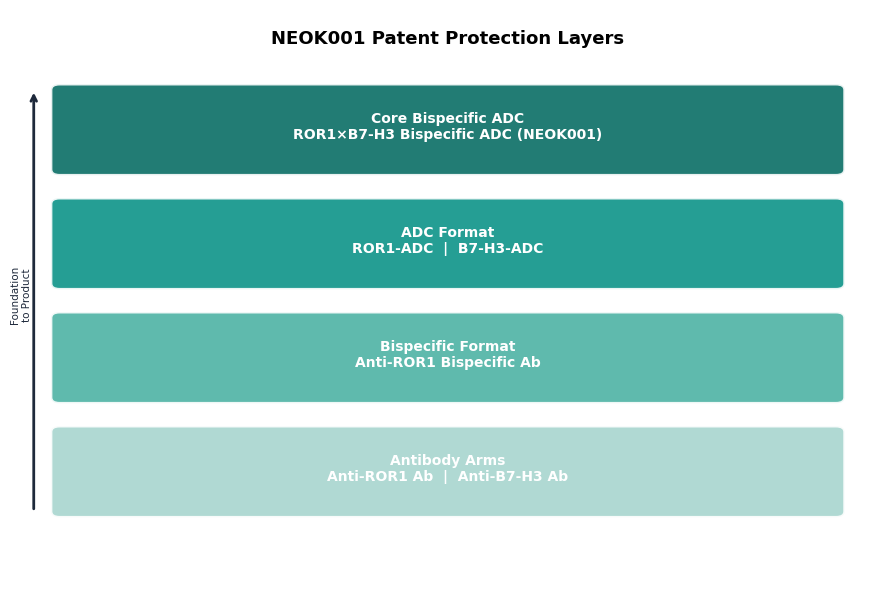

In [83]:
layer_colors = {
    'Antibody Arms': '#A8D5CF',       # lightest
    'Bispecific Format': '#4DB3A4',   # medium
    'ADC Format': '#0D9488',          # dark teal
    'Core Bispecific ADC': '#0A6E65', # darkest
}

fig1, ax1 = plt.subplots(figsize=(9, 6))
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

layers = [
    ('Antibody Arms', 'Anti-ROR1 Ab  |  Anti-B7-H3 Ab', 1.2),
    ('Bispecific Format', 'Anti-ROR1 Bispecific Ab', 3.2),
    ('ADC Format', 'ROR1-ADC  |  B7-H3-ADC', 5.2),
    ('Core Bispecific ADC', 'ROR1×B7-H3 Bispecific ADC (NEOK001)', 7.2),
]

for layer, desc, y in layers:
    color = layer_colors[layer]
    rect = mpatches.FancyBboxPatch((0.5, y), 9, 1.4,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, alpha=0.9,
                                    edgecolor='white', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(5, y + 0.75, f"{layer}\n{desc}",
             ha='center', va='center', fontsize=10,
             fontweight='bold', color='white')

# arrow bottom to top
ax1.annotate('', xy=(0.2, 8.6), xytext=(0.2, 1.2),
             arrowprops=dict(arrowstyle='->', color='#1E293B', lw=2))
ax1.text(0.05, 5, 'Foundation\nto Product', fontsize=7.5,
         color='#1E293B', va='center', ha='center', rotation=90)

ax1.text(5, 9.5, 'NEOK001 Patent Protection Layers',
         ha='center', va='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

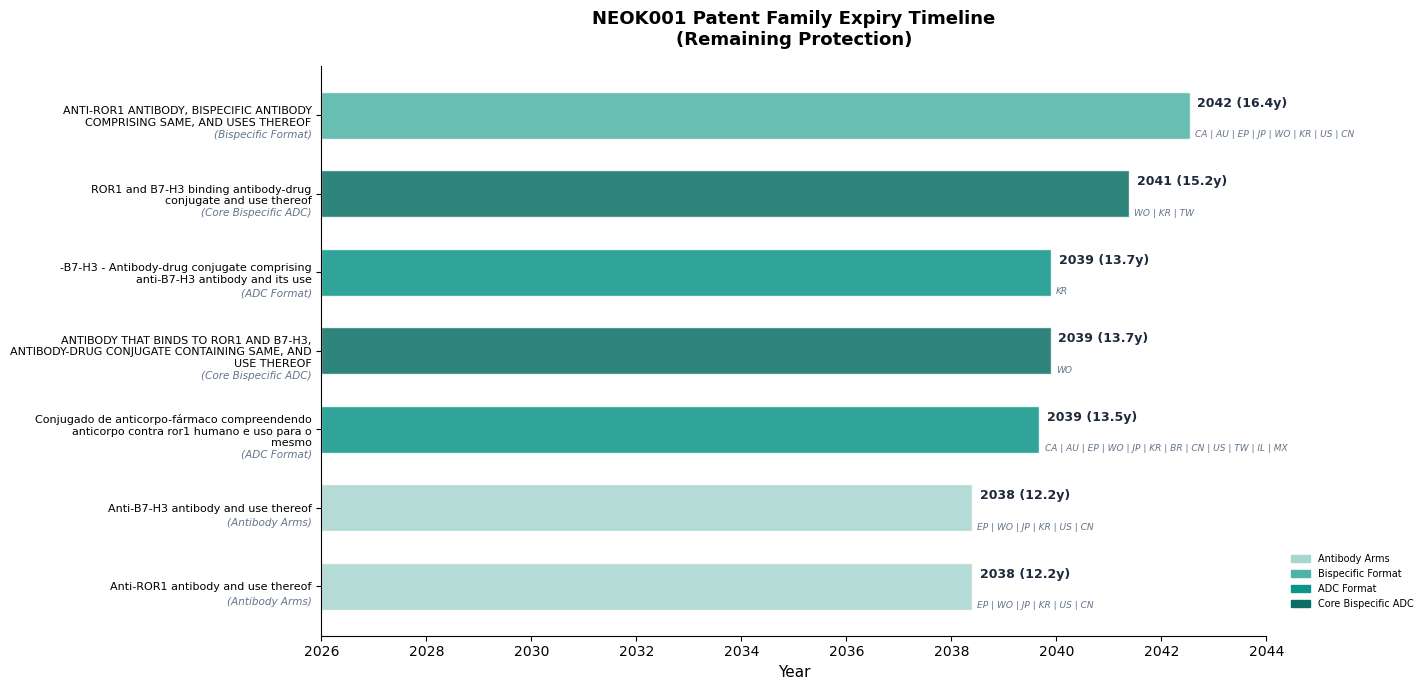

In [82]:
import textwrap

# build jurisdiction dict (determined after running code block below)
jur_dict = {}
for _, row in neok001_df_sorted.iterrows():
    jur = own_abl[own_abl['Lens ID'] == row['lens_id']]['Simple Family Member Jurisdictions'].values[0]
    # clean up, remove WO, keep key ones
    jurs = [j.strip() for j in jur.split(';;') if j.strip() != ''] 
    jur_dict[row['lens_id']] = ' | '.join(jurs)

fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, row in neok001_df_sorted.iterrows():
    color = layer_colors[row['layer']]
    start = max(row['priority_date'].year + row['priority_date'].dayofyear / 365, 2026)
    end = row['expiry_date'].year + row['expiry_date'].dayofyear / 365
    width = end - start

    ax2.barh(i, width, left=start, height=0.6,
             color=color, alpha=0.85, edgecolor='white', linewidth=1)
    
    # expiry year
    ax2.text(end + 0.15, i + 0.15, f"{row['expiry_date'].year} ({row['years_to_expiry']:.1f}y)",
             va='center', fontsize=9, color='#1E293B', fontweight='bold')
    
    # jurisdiction tags below expiry year
    ax2.text(end + 0.1, i - 0.25, jur_dict[row['lens_id']],
             va='center', fontsize=6.5, color='#64748B', style='italic')

ax2.set_yticks(range(len(neok001_df_sorted)))
ax2.set_yticklabels([textwrap.fill(row['title'], width=45) #for titles on the left side of chart
                      for _, row in neok001_df_sorted.iterrows()], fontsize=8)

# add layer (text in brackets below title) in italics as separate text
# manual offsets per row index
manual_offsets = {
    0: -0.2,   # 7th bar
    1: -0.2,   # 6th bar
    2: -0.32,   # 5th bar
    3: -0.32,  # 4th bar
    4: -0.27,  # 3rd bar
    5: -0.25,   # 2nd bar
    6: -0.25,   # 1st bar
}

for i, row in neok001_df_sorted.iterrows():
    offset = manual_offsets.get(i, -0.2)
    ax2.text(-0.01, i + offset, f"({row['layer']})",
             transform=ax2.get_yaxis_transform(),
             fontsize=7.5, style='italic', color='#64748B',
             ha='right', va='center')

ax2.set_xlim(2026, 2044)  # could set extra room for jurisdiction text by increase 2044
ax2.set_xticks(range(2026, 2046, 2)) # integer ticks every year
ax2.tick_params(axis='x', rotation=0)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title('NEOK001 Patent Family Expiry Timeline\n(Remaining Protection)',
              fontsize=13, fontweight='bold', pad=15)
ax2.spines[['top', 'right']].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in layer_colors.items()]
ax2.legend(handles=legend_patches, fontsize=7,
           bbox_to_anchor=(1.16, 0.15), loc='upper right', borderaxespad=0,frameon=False)

fig2.subplots_adjust(left=0.35, right=0.78)
plt.tight_layout()
plt.show()

In [ ]:
#Check what flags are needed for above code
for _, row in neok001_df_sorted.iterrows():
    jur = own_abl[own_abl['Lens ID'] == row['lens_id']]['Simple Family Member Jurisdictions'].values[0]
    print(f"{row['short_title'][:40]}: {jur}")

Anti-ROR1 antibody and use thereof: EP;;WO;;JP;;KR;;US;;CN
Anti-B7-H3 antibody and use thereof: EP;;WO;;JP;;KR;;US;;CN
Conjugado de anticorpo-fármaco compreend: CA;;AU;;EP;;WO;;JP;;KR;;BR;;CN;;US;;TW;;IL;;MX
ANTIBODY THAT BINDS TO ROR1 AND B7-H3, A: WO
-B7-H3 - Antibody-drug conjugate compris: KR
ROR1 and B7-H3 binding antibody-drug con: WO;;KR;;TW
ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY : CA;;AU;;EP;;JP;;WO;;KR;;US;;CN


In [ ]:
# build jurisdiction dict
jur_dict = {}
for _, row in neok001_df_sorted.iterrows():
    jur = own_abl[own_abl['Lens ID'] == row['lens_id']]['Simple Family Member Jurisdictions'].values[0]
    # clean up, remove WO, keep key ones
    jurs = [j.strip() for j in jur.split(';;') if j.strip() not in ['WO', '']]
    jur_dict[row['lens_id']] = ' | '.join(jurs) if jurs else 'WO only'

fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, row in neok001_df_sorted.iterrows():
    color = layer_colors[row['layer']]
    start = max(row['priority_date'].year + row['priority_date'].dayofyear / 365, 2026)
    end = row['expiry_date'].year + row['expiry_date'].dayofyear / 365
    width = end - start

    ax2.barh(i, width, left=start, height=0.6,
             color=color, alpha=0.85, edgecolor='white', linewidth=1)
    
    # expiry year
    ax2.text(end + 0.1, i + 0.25, f"{row['expiry_date'].year} ({row['years_to_expiry']:.1f}y)",
             va='center', fontsize=8, color='#1E293B')
    
    # jurisdiction tags below expiry year
    ax2.text(end + 0.1, i - 0.25, jur_dict[row['lens_id']],
             va='center', fontsize=6.5, color='#64748B', style='italic')

ax2.set_yticks(range(len(neok001_df_sorted)))
ax2.set_yticklabels([f"{textwrap.fill(row['title'], width=40)}\n({row['layer']})"
                      for _, row in neok001_df_sorted.iterrows()], fontsize=8)

ax2.set_xlim(2026, 2048)  # extra room for jurisdiction text
ax2.set_xticks(range(2026, 2046, 1))
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title('NEOK001 Patent Family Expiry Timeline\n(Remaining Protection)',
              fontsize=13, fontweight='bold', pad=15)
ax2.spines[['top', 'right']].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in layer_colors.items()]
ax2.legend(handles=legend_patches, fontsize=8,
           bbox_to_anchor=(1.15, 1), loc='upper right', borderaxespad=0)

fig2.subplots_adjust(left=0.35, right=0.78)
plt.tight_layout()
plt.show()